<a href="https://colab.research.google.com/github/ryukf333/remote-sensing-crop-yield-ml/blob/main/04basline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount Drive and load the clean master table
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/remote-sensing-crop-yield-ml/data_processed/iowa_master_modeling_2022.csv')

# 2. Define Predictors (X) and Target (y)
features = ['ndvi_mean_jul', 'temp_k_jul', 'soil_water_jul']
X = df[features]
y = df['yield_bu_ac']

# 3. Spatial Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} counties, Testing on {len(X_test)} counties.")

Mounted at /content/drive
Training on 76 counties, Testing on 19 counties.


In [ ]:
# 1. Initialize Models
models = {
    'Mean Baseline': None,
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

# 2. Evaluate Mean Baseline (Predicting the training average for every test county)
y_pred_mean = np.full(shape=y_test.shape, fill_value=y_train.mean())
results.append({
    'Model': 'Mean Baseline',
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_mean)),
    'R2': r2_score(y_test, y_pred_mean)
})

# 3. Train and Evaluate ML Models
for name, model in list(models.items())[1:]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

# 4. Display benchmark table
results_df = pd.DataFrame(results).round(3)
display(results_df)

,Model,RMSE,R2
0,Mean Baseline,23.597,-0.001
1,Ridge Regression,14.579,0.618
2,Random Forest,12.927,0.699


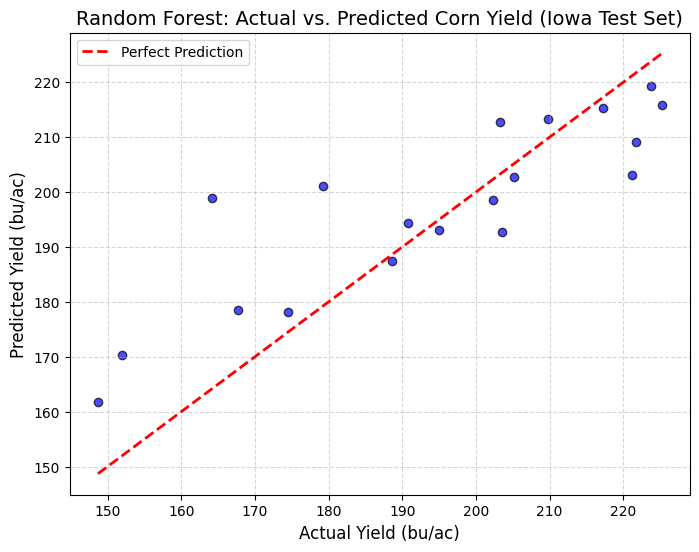

In [ ]:

rf_model = models['Random Forest']
rf_preds = rf_model.predict(X_test)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.7, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Yield (bu/ac)', fontsize=12)
plt.ylabel('Predicted Yield (bu/ac)', fontsize=12)
plt.title('Random Forest: Actual vs. Predicted Corn Yield (Iowa Test Set)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# 1. Set up 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Compute cross-validated R2 and RMSE across all 95 counties
cv_r2 = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X, y, cv=kf, scoring='r2')
cv_mse = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X, y, cv=kf, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_mse)

print(f"5-Fold Cross-Validated R2:   {cv_r2.mean():.3f} (+/- {cv_r2.std():.3f})")
print(f"5-Fold Cross-Validated RMSE: {cv_rmse.mean():.3f} (+/- {cv_rmse.std():.3f}) bu/ac")

5-Fold Cross-Validated R2:   0.618 (+/- 0.172)
5-Fold Cross-Validated RMSE: 11.968 (+/- 1.213) bu/ac


# SHAP Analysis

Model fitted for SHAP analysis.


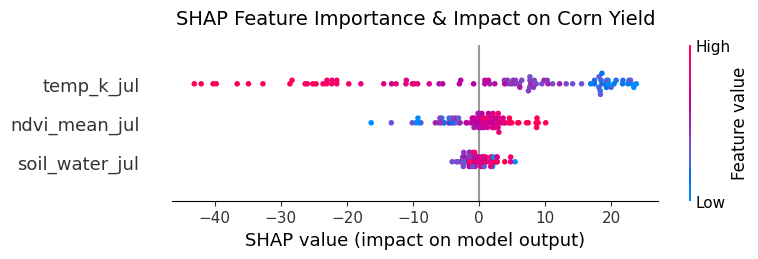

Figure saved to /content/drive/MyDrive/remote-sensing-crop-yield-ml/figures/figure_6_beeswarm.png


In [ ]:
import shap

features = ['ndvi_mean_jul', 'temp_k_jul', 'soil_water_jul']
X = df[features]
y = df['yield_bu_ac']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
print("Model fitted for SHAP analysis.")

# 1. Initialize TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

# 2. Plot the Beeswarm distribution (Figure 6 in the project outline)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP Feature Importance & Impact on Corn Yield", fontsize=14, pad=15)
plt.tight_layout()
outp_fig = '/content/drive/MyDrive/remote-sensing-crop-yield-ml/figures/figure_6_beeswarm.png'
plt.savefig(outp_fig, dpi=300)
plt.show()



print(f"Figure saved to {outp_fig}")

<Figure size 800x600 with 0 Axes>

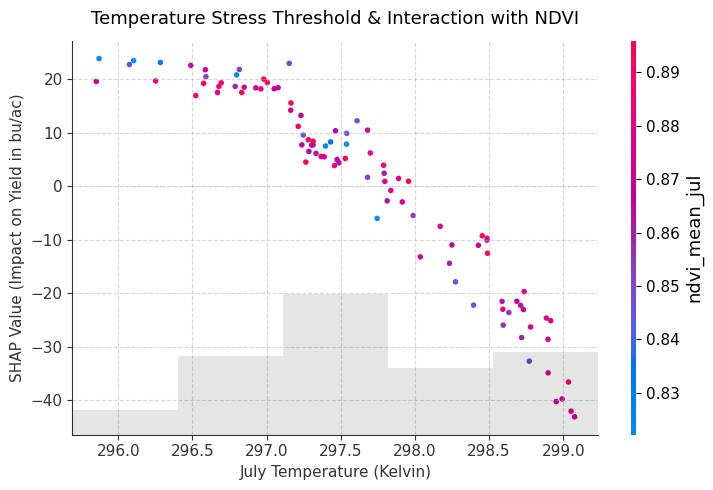

In [ ]:
# Generate a SHAP dependence plot for July Temperature
# This reveals the exact threshold where high heat causes yield to collapse
plt.figure(figsize=(8, 6))
shap.plots.scatter(shap_values[:, "temp_k_jul"], color=shap_values[:, "ndvi_mean_jul"], show=False)
plt.title("Temperature Stress Threshold & Interaction with NDVI", fontsize=13, pad=12)
plt.xlabel("July Temperature (Kelvin)", fontsize=11)
plt.ylabel("SHAP Value (Impact on Yield in bu/ac)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Maps

In [ ]:
import ee
import geemap
import pandas as pd
import geopandas as gpd
import os

ee.Authenticate()
ee.Initialize(project='ee-crop-yield-2026')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [ ]:
# 2. Set Paths
processed_dir = '/content/drive/MyDrive/remote-sensing-crop-yield-ml/data_processed'
figures_dir = '/content/drive/MyDrive/remote-sensing-crop-yield-ml/figures'

# 3. Load dataset
df = pd.read_csv(os.path.join(processed_dir, 'iowa_master_modeling_2022.csv'))
df['county_fips'] = df['county_fips'].astype(str).str.zfill(3)

# 4. Fit model and compute predictions & residuals
features = ['ndvi_mean_jul', 'temp_k_jul', 'soil_water_jul']
X = df[features]
y = df['yield_bu_ac']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

df['predicted_yield'] = rf.predict(X)
df['residual_error'] = df['yield_bu_ac'] - df['predicted_yield']

print("Predictions and residuals calculated.")

Predictions and residuals calculated.


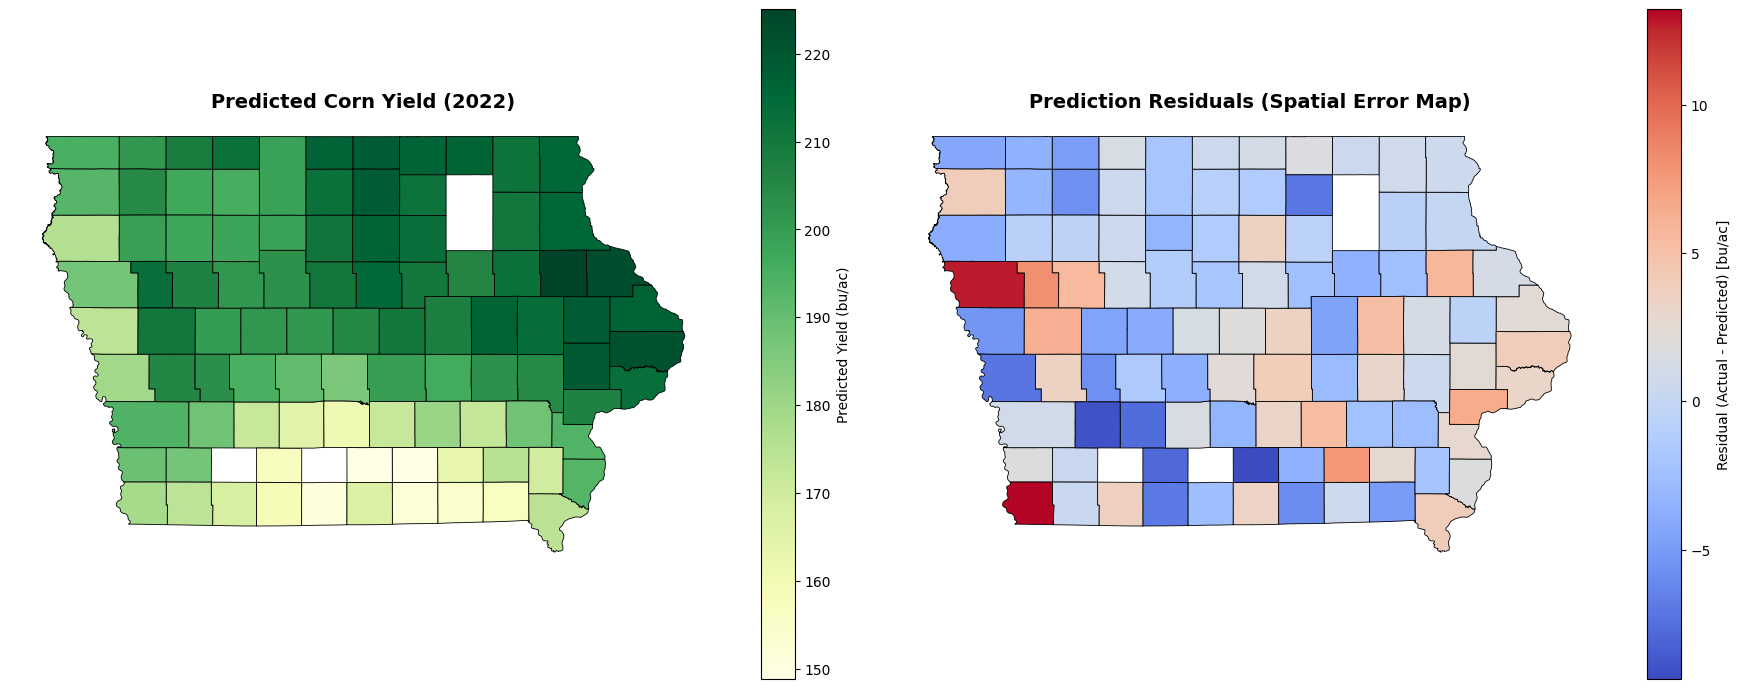

Figure saved to /content/drive/MyDrive/remote-sensing-crop-yield-ml/figures/figure_7_spatial_prediction_error.png


In [ ]:
# 1. Load Iowa counties from Earth Engine and convert to GeoPandas
counties_ee = ee.FeatureCollection("TIGER/2018/Counties").filter(ee.Filter.eq('STATEFP', '19'))
gdf_counties = geemap.ee_to_gdf(counties_ee)
gdf_counties['county_fips'] = gdf_counties['COUNTYFP'].astype(str).str.zfill(3)

# 2. Merge geometries with our prediction table
map_gdf = gdf_counties.merge(df, on='county_fips', how='inner')

# 3. Generate side-by-side spatial maps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Map A: Predicted Yield
map_gdf.plot(
    column='predicted_yield',
    cmap='YlGn',
    linewidth=0.6,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Predicted Yield (bu/ac)'},
    ax=axes[0]
)
axes[0].set_title('Predicted Corn Yield (2022)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Map B: Residual Error (Actual - Predicted)
map_gdf.plot(
    column='residual_error',
    cmap='coolwarm',
    linewidth=0.6,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Residual (Actual - Predicted) [bu/ac]'},
    ax=axes[1]
)
axes[1].set_title('Prediction Residuals (Spatial Error Map)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# 4. Save and display the figure
plt.tight_layout()
out_fig = os.path.join(figures_dir, 'figure_7_spatial_prediction_error.png')
plt.savefig(out_fig, dpi=300)
plt.show()

print(f"Figure saved to {out_fig}")

# Forecasting

In [ ]:
counties = ee.FeatureCollection("TIGER/2018/Counties").filter(ee.Filter.eq('STATEFP', '19'))
corn_mask = ee.Image("USDA/NASS/CDL/2022").select('cropland').eq(1)

def add_ndvi(image):
    return image.addBands(image.normalizedDifference(['B8', 'B4']).rename('NDVI'))

# Function to extract monthly median NDVI + monthly mean weather for Iowa
def extract_month_features(start_date, end_date, suffix):
    # Sentinel-2 NDVI
    s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(counties) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .map(add_ndvi) \
        .select('NDVI') \
        .median() \
        .updateMask(corn_mask)

    s2_stats = s2.reduceRegions(collection=counties, reducer=ee.Reducer.mean(), scale=30)
    df_s2 = geemap.ee_to_df(s2_stats)[['COUNTYFP', 'mean']].rename(columns={'mean': f'ndvi_{suffix}', 'COUNTYFP': 'county_fips'})
    df_s2['county_fips'] = df_s2['county_fips'].astype(str).str.zfill(3)

    # ERA5-Land Weather
    era5 = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR") \
        .filterDate(start_date, end_date) \
        .first() \
        .select(['temperature_2m', 'volumetric_soil_water_layer_1'])

    era5_stats = era5.reduceRegions(collection=counties, reducer=ee.Reducer.mean(), scale=9000)
    df_era5 = geemap.ee_to_df(era5_stats)[['COUNTYFP', 'temperature_2m', 'volumetric_soil_water_layer_1']].rename(columns={
        'COUNTYFP': 'county_fips',
        'temperature_2m': f'temp_{suffix}',
        'volumetric_soil_water_layer_1': f'soil_water_{suffix}'
    })
    df_era5['county_fips'] = df_era5['county_fips'].astype(str).str.zfill(3)

    return df_s2.merge(df_era5, on='county_fips')

print("Helper function defined.")

Helper function defined.


In [ ]:
# 1. Extract June and August
print("Extracting June features...")
df_jun = extract_month_features('2022-06-01', '2022-06-30', 'jun')

print("Extracting August features...")
df_aug = extract_month_features('2022-08-01', '2022-08-31', 'aug')

# 2. Load existing July table
processed_dir = '/content/drive/MyDrive/remote-sensing-crop-yield-ml/data_processed'
df_jul_master = pd.read_csv(os.path.join(processed_dir, 'iowa_master_modeling_2022.csv'))
df_jul_master['county_fips'] = df_jul_master['county_fips'].astype(str).str.zfill(3)

# 3. Merge all months into a full growing season table
df_forecast = df_jul_master.merge(df_jun, on='county_fips', how='inner')
df_forecast = df_forecast.merge(df_aug, on='county_fips', how='inner')

# Drop any observation gaps across all months to maintain a common test cohort
df_forecast = df_forecast.dropna().reset_index(drop=True)
print(f"Final multi-window dataset assembled: {len(df_forecast)} counties.")
display(df_forecast.head(2))

Extracting June features...
Extracting August features...
Final multi-window dataset assembled: 95 counties.


,state_fips,county_fips,county,year,yield_bu_ac,ndvi_mean_jul,temp_k_jul,soil_water_jul,ndvi_jun,temp_jun,soil_water_jun,ndvi_aug,temp_aug,soil_water_aug
0,19,001,ADAIR,2022,164.2,0.817093,297.745176,0.263439,0.473744,296.099550,0.317616,0.775273,297.255551,0.227047
1,19,005,ALLAMAKEE,2022,215.9,0.848514,296.075046,0.329033,0.392452,294.037646,0.346317,0.877007,294.954747,0.342024


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score


y = df_forecast['yield_bu_ac']
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define feature sets strictly constrained by calendar cutoff dates
cutoffs = {
    'June 30 (Vegetative)': ['ndvi_jun', 'temp_jun', 'soil_water_jun'],
    'July 31 (+ Peak/Pollination)': ['ndvi_jun', 'temp_jun', 'soil_water_jun',
                                    'ndvi_mean_jul', 'temp_k_jul', 'soil_water_jul'],
    'August 31 (+ Maturation)': ['ndvi_jun', 'temp_jun', 'soil_water_jun',
                                 'ndvi_mean_jul', 'temp_k_jul', 'soil_water_jul',
                                 'ndvi_aug', 'temp_aug', 'soil_water_aug']
}

benchmark = []

for date_name, cols in cutoffs.items():
    X = df_forecast[cols]
    r2_scores = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X, y, cv=kf, scoring='r2')
    mse_scores = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X, y, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-mse_scores)

    benchmark.append({
        'Cutoff Date': date_name,
        'Features Used': len(cols),
        'CV R2': r2_scores.mean(),
        'CV RMSE (bu/ac)': rmse_scores.mean()
    })

df_bench = pd.DataFrame(benchmark).round(3)
display(df_bench)

,Cutoff Date,Features Used,CV R2,CV RMSE (bu/ac)
0,June 30 (Vegetative),3,0.630,11.601
1,July 31 (+ Peak/Pollination),6,0.667,10.846
2,August 31 (+ Maturation),9,0.689,10.721


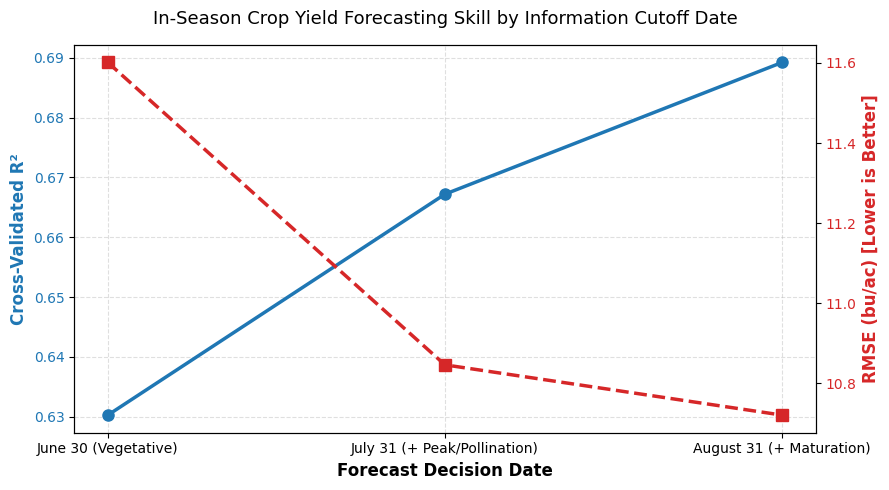

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 5))

dates = [b['Cutoff Date'] for b in benchmark]
r2_vals = [b['CV R2'] for b in benchmark]
rmse_vals = [b['CV RMSE (bu/ac)'] for b in benchmark]

color = 'tab:blue'
ax1.set_xlabel('Forecast Decision Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cross-Validated R²', color=color, fontsize=12, fontweight='bold')
ax1.plot(dates, r2_vals, color=color, marker='o', linewidth=2.5, markersize=8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('RMSE (bu/ac) [Lower is Better]', color=color, fontsize=12, fontweight='bold')
ax2.plot(dates, rmse_vals, color=color, marker='s', linestyle='--', linewidth=2.5, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('In-Season Crop Yield Forecasting Skill by Information Cutoff Date', fontsize=13, pad=15)
fig.tight_layout()

figures_dir = '/content/drive/MyDrive/remote-sensing-crop-yield-ml/figures'
plt.savefig(os.path.join(figures_dir, 'figure_forecast_progression_curve.png'), dpi=300)
plt.show()